# `find_floating_solid`
Locates clusters of solid voxels that are not attached to the main solid structure. This is the solid-phase counterpart of `find_disconnected_voxels`.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.find_floating_solid)

<Signature (im: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]], conn: Literal['max', 'min'] = 'min', incl_surface: bool = False)>

## `im`
A boolean image with `True` indicating the void phase (i.e. the same convention as everywhere else in PoreSpy). Floating solid is solid that is not connected to any face of the image.

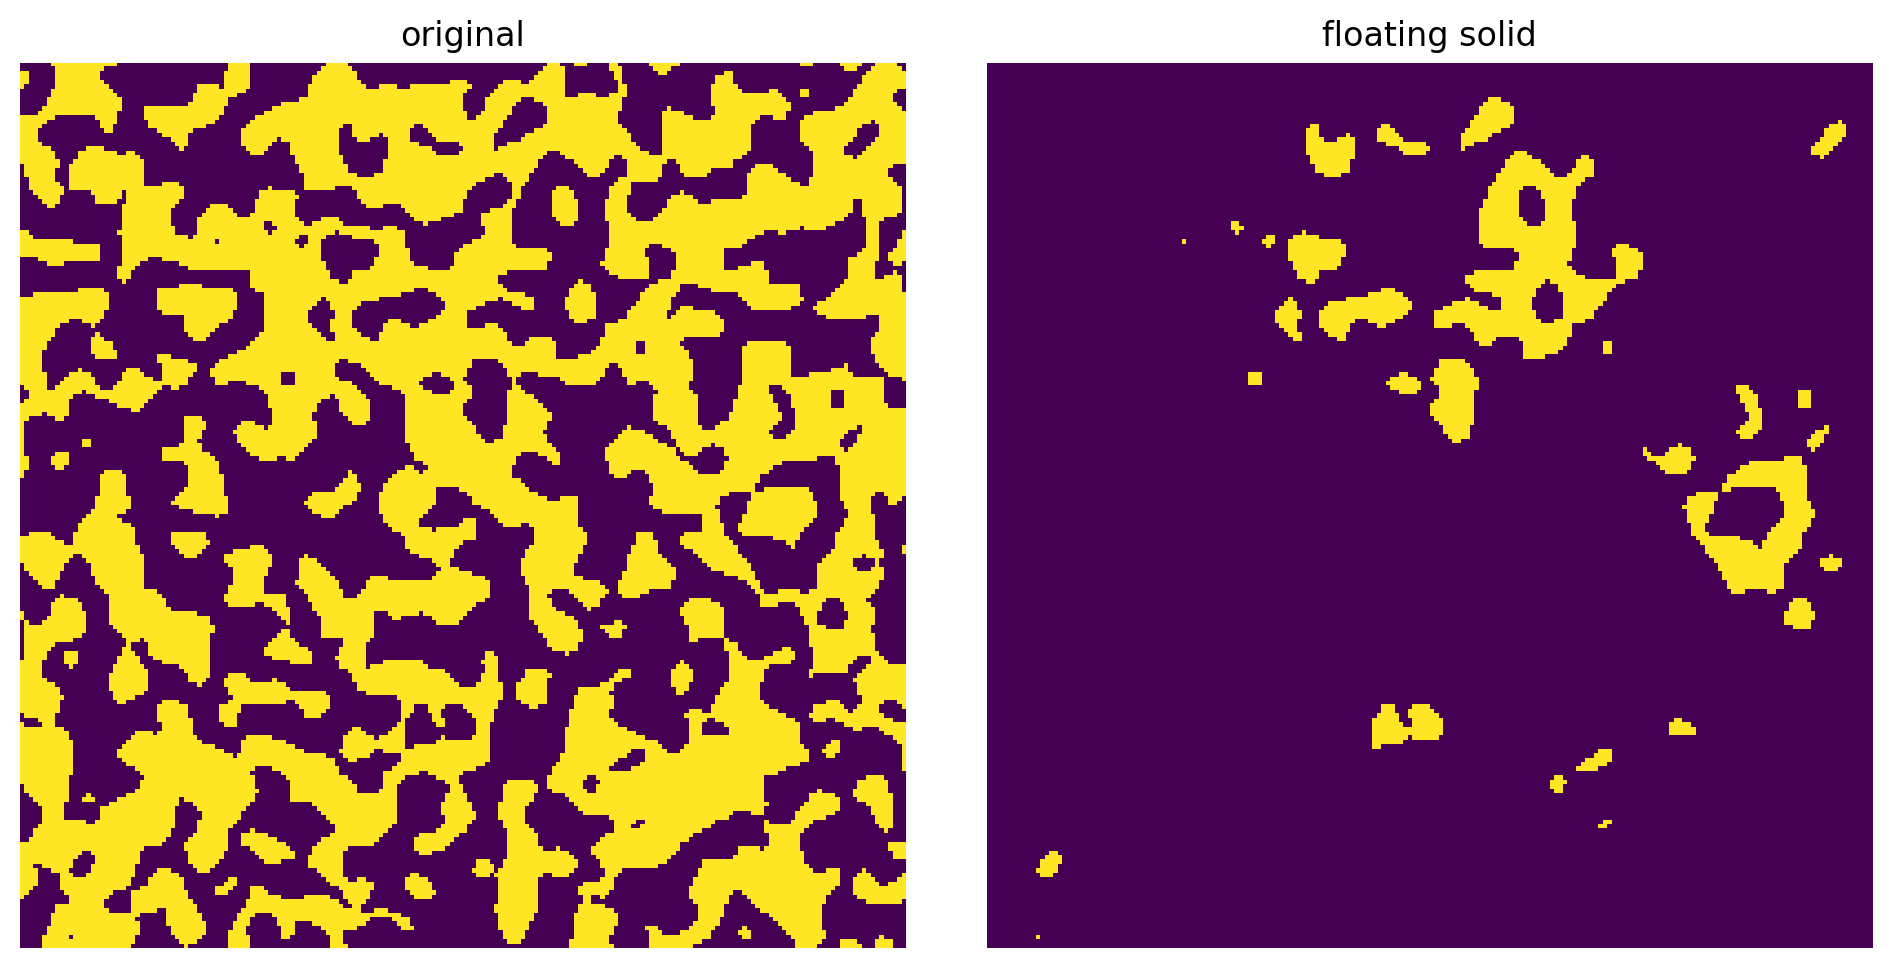

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.5, blobiness=2, seed=1)
floating = ps.filters.find_floating_solid(im=im)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(im, origin='lower', interpolation='none')
ax[0].set_title('original')
ax[0].axis(False)
ax[1].imshow(floating, origin='lower', interpolation='none')
ax[1].set_title('floating solid')
ax[1].axis(False);

## `conn`
Controls voxel connectivity. `'min'` (default) requires shared faces; `'max'` accepts edges and corners. Looser connectivity merges more solid clusters into the main body, so fewer voxels are flagged as floating.

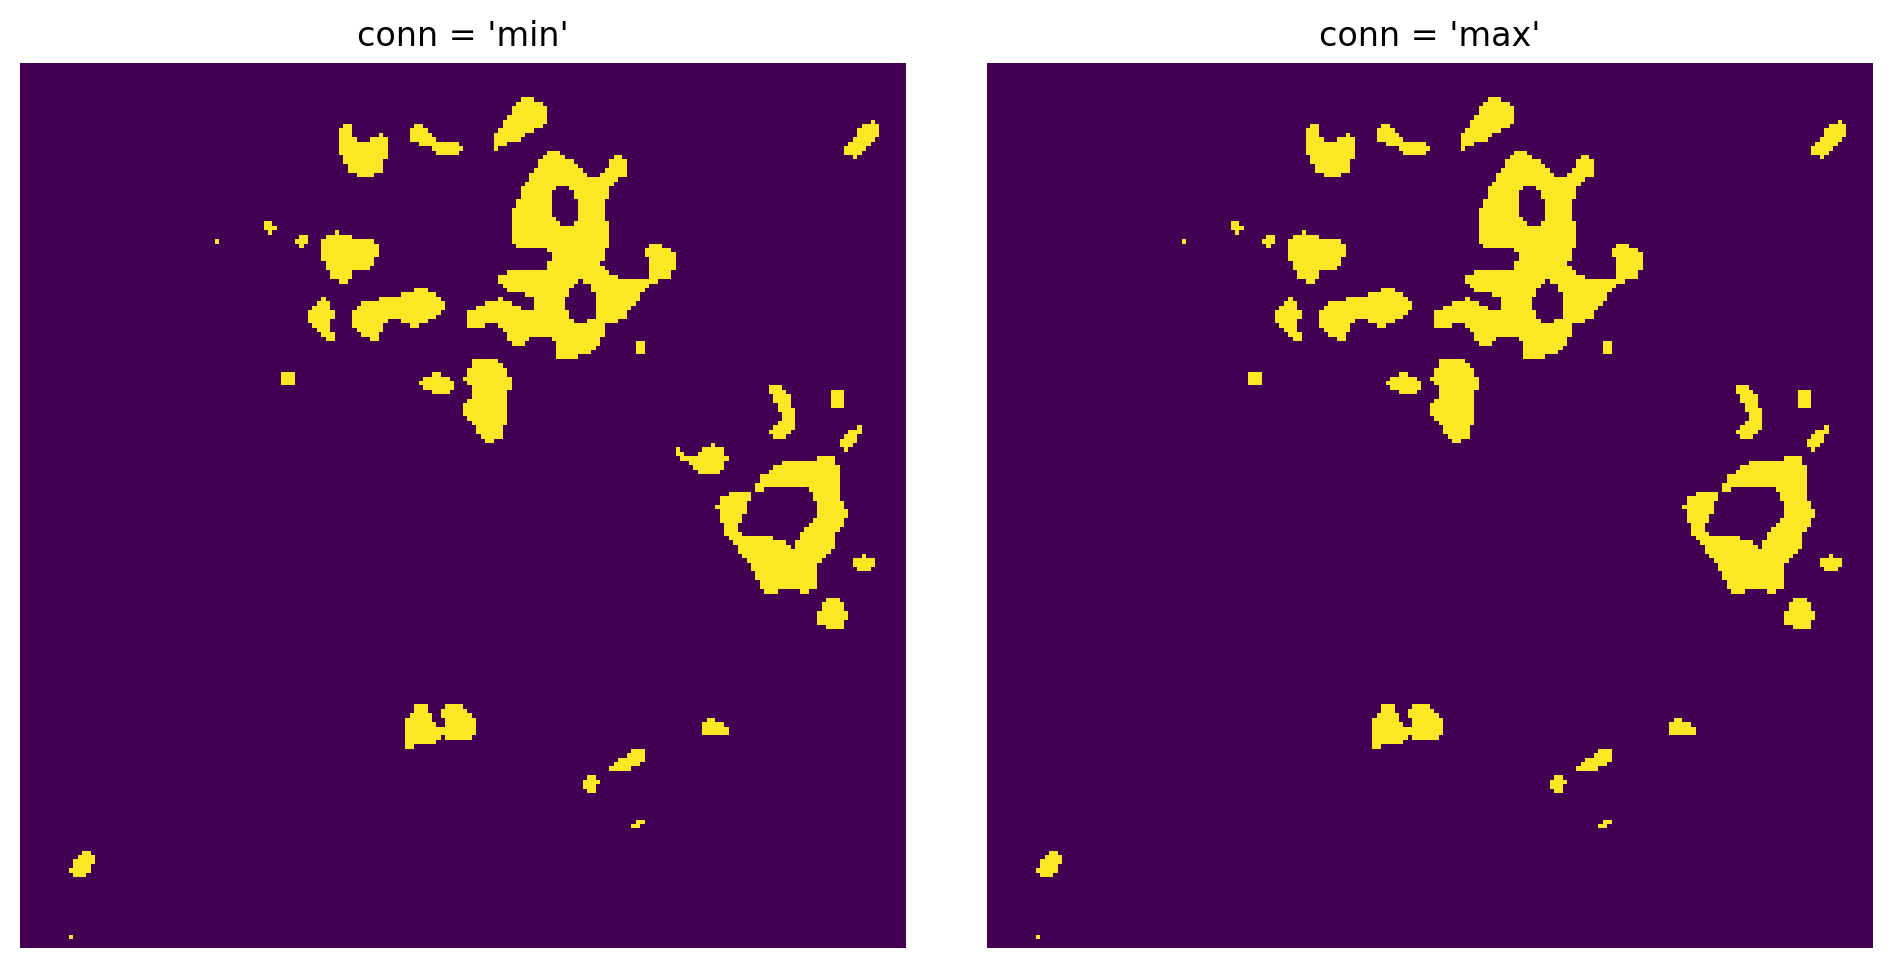

In [4]:
floating_min = ps.filters.find_floating_solid(im=im, conn='min')
floating_max = ps.filters.find_floating_solid(im=im, conn='max')

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(floating_min, origin='lower', interpolation='none')
ax[0].set_title("conn = 'min'")
ax[0].axis(False)
ax[1].imshow(floating_max, origin='lower', interpolation='none')
ax[1].set_title("conn = 'max'")
ax[1].axis(False);

## `incl_surface`
When `True`, solid clusters that touch a face but do not span the domain are also flagged. This is useful when a thin solid skin near the boundary is undesirable (for example, when preparing an image for transport simulations).

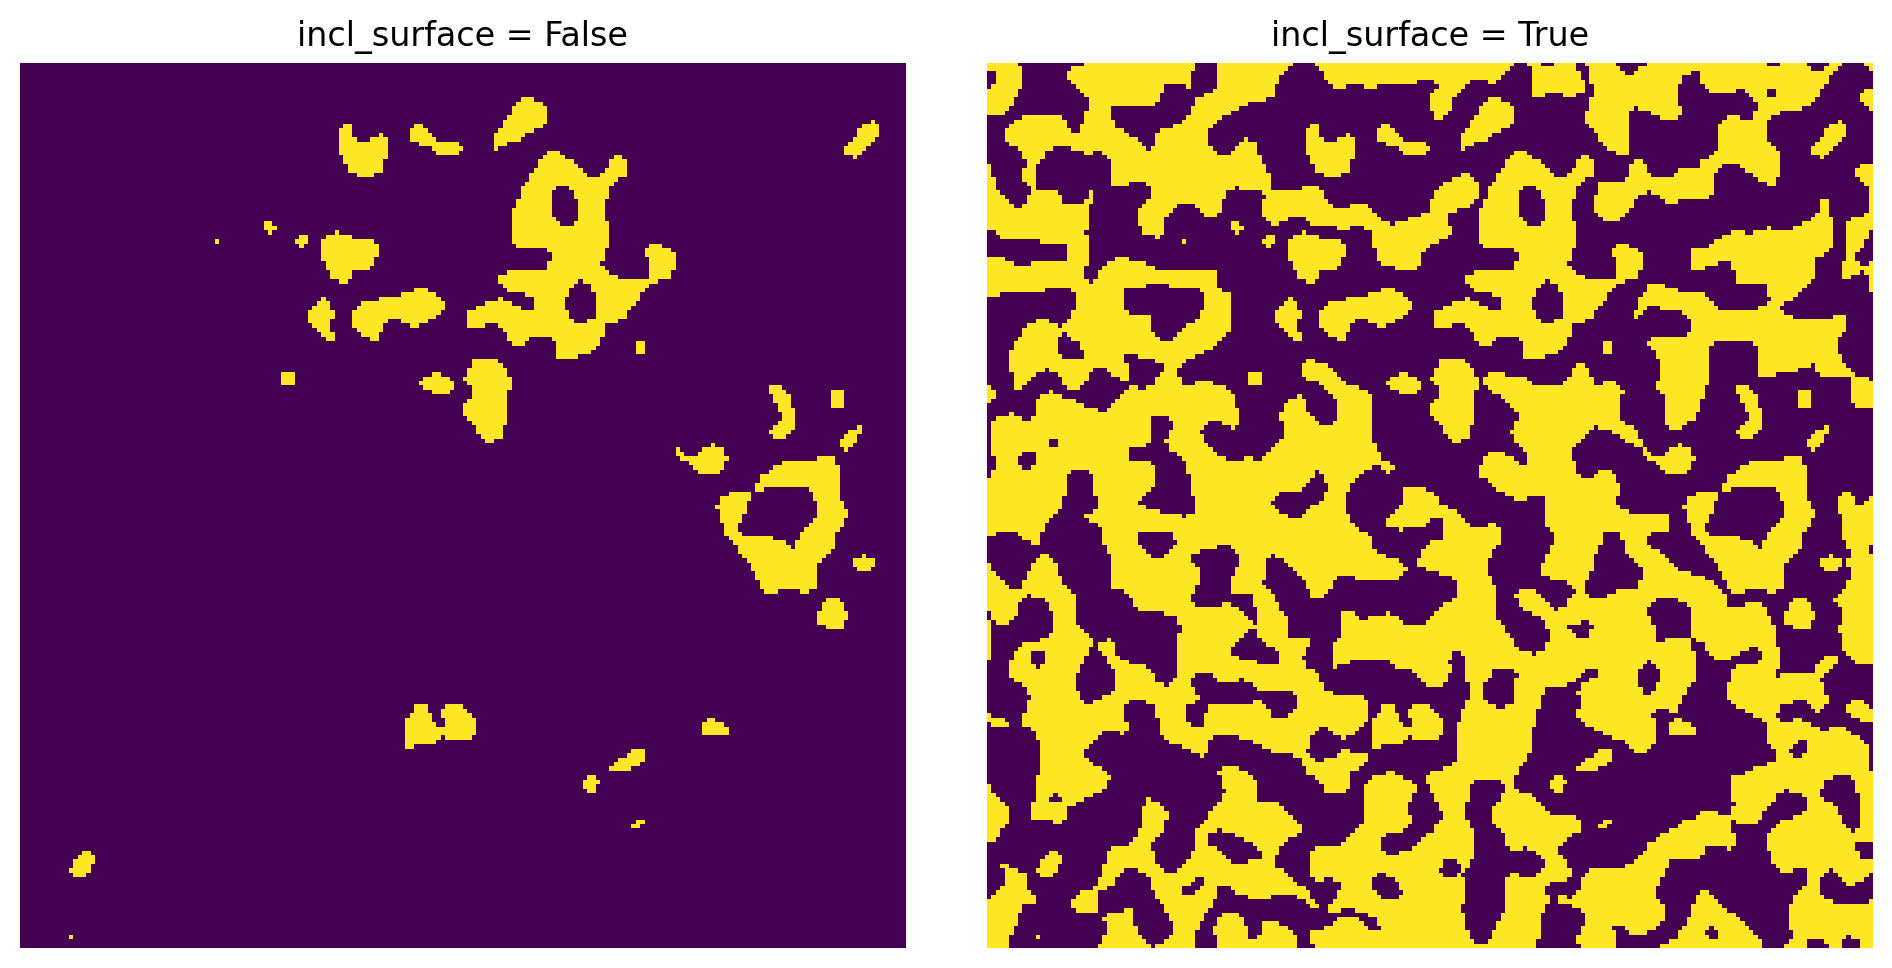

In [5]:
floating = ps.filters.find_floating_solid(im=im, incl_surface=False)
floating_surf = ps.filters.find_floating_solid(im=im, incl_surface=True)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(floating, origin='lower', interpolation='none')
ax[0].set_title('incl_surface = False')
ax[0].axis(False)
ax[1].imshow(floating_surf, origin='lower', interpolation='none')
ax[1].set_title('incl_surface = True')
ax[1].axis(False);